In [1]:
from ftlelab import *
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

%matplotlib inline

## Preparing the Cricles Data:

In [2]:
total_samples = 15000

In [3]:
X, y = make_circle_dataset(num_samples=total_samples,
                                   radius=0.5,
                                   noise_var=0,
                                   seed = 312)

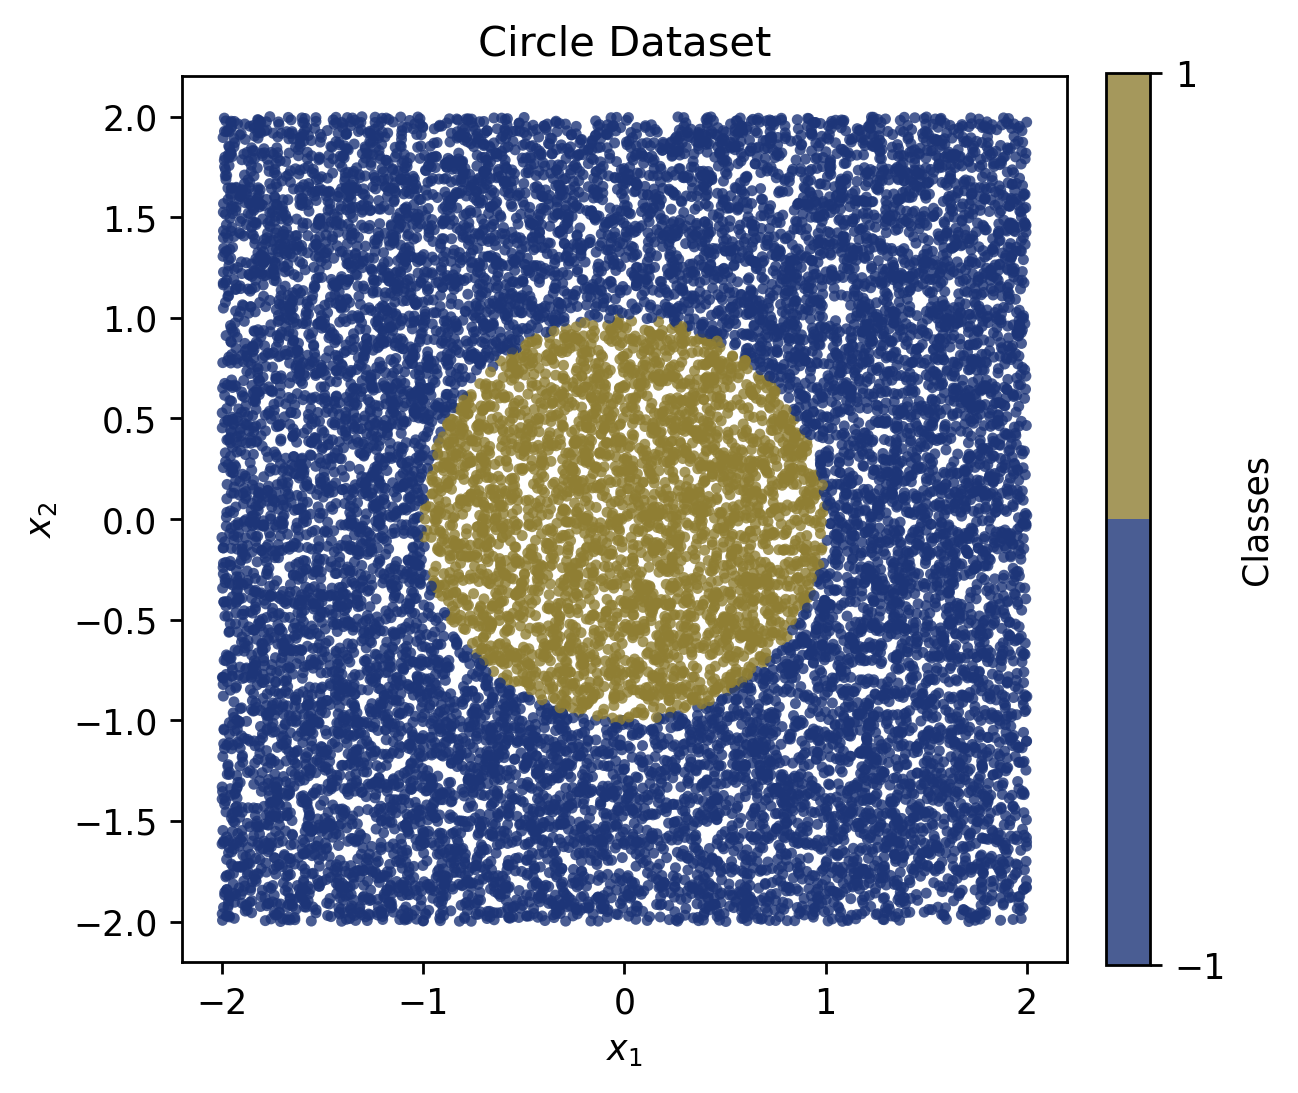

In [4]:
cmap = ListedColormap(['#1d3578', '#8f7e33'])

plt.figure(figsize=(5,5), dpi=250)
plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap, s=10, alpha=0.8, edgecolors='none')
plt.gca().set_aspect('equal', 'box')
plt.colorbar(ticks=[-1,1], label='Classes', fraction=0.046, pad=0.04)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Circle Dataset')
plt.show()

### Experimenting with Dropout

In [3]:
config_drop = TrainConfig(
    lr=0.05,
    epochs=2000,
    batch_size=train_size,
    loss='mse', # CrossEntropyLoss for multi-class classification
    optimizer='sgd',
    weight_decay=0.0,
    save_dir='my_classification_models/saved_models',
    model_name='(63, 10)-dropout_20',
    momentum=0.0,
    print_every=100
)

In [4]:
# --- 2. Setup Config and DataLoaders ---
config_nodrop = TrainConfig(
    lr=0.05,
    epochs=2000,
    batch_size=train_size,
    loss='mse', # CrossEntropyLoss for multi-class classification
    optimizer='sgd',
    weight_decay=0.0,
    save_dir='my_classification_models/saved_models',
    model_name='(50, 10)',
    momentum=0.0,
    print_every=100
)

train_loader = DataLoader(train_data, batch_size=config_drop.batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=config_drop.batch_size)

In [48]:
model_drop = CustomDNN(63, 10, 2, 1, dropout=0.2) #(10, 5, 2, 1)
trainer_drop = Trainer(model=model_drop, cfg=config_drop)

Trainer for MODEL_(63, 10)-dropout_20 was initialized on device: {self.device}


In [ ]:
model_nodrop = CustomDNN(50, 10, 2, 1) #(10, 5, 2, 1)
trainer_nodrop = Trainer(model=model_nodrop, cfg=config_nodrop)

Trainer for MODEL_(100, 10)-dropout was initialized on device: {self.device}
Trainer for MODEL_(50, 10) was initialized on device: {self.device}


In [49]:
# --- 4. Run Training ---
history_drop = trainer_drop.train(train_loader=train_loader, val_loader=val_loader)

Training started...


Epoch 100/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 207.70it/s]


Epoch 100/2000 | Train Loss: 0.6516 | Val Loss: 0.5622 | Val Acc: 83.00%


Epoch 200/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 126.42it/s]


Epoch 200/2000 | Train Loss: 0.6370 | Val Loss: 0.5550 | Val Acc: 83.00%
Validation loss improved from 0.5552 to 0.5550. Saving the best model.


...

Epoch 1800/2000 | Train Loss: 0.1074 | Val Loss: 0.0136 | Val Acc: 100.00%


Epoch 1900/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 97.88it/s]


Epoch 1900/2000 | Train Loss: 0.1125 | Val Loss: 0.0165 | Val Acc: 100.00%


Epoch 2000/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 138.72it/s]

Epoch 2000/2000 | Train Loss: 0.1077 | Val Loss: 0.0156 | Val Acc: 100.00%
Training finished.


In [6]:
history_nodrop = trainer_nodrop.train(train_loader=train_loader, val_loader=val_loader)

Training started...


Epoch 100/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 127.30it/s]


Epoch 100/2000 | Train Loss: 0.1437 | Val Loss: 0.2525 | Val Acc: 92.50%


Epoch 200/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 193.44it/s]


Epoch 200/2000 | Train Loss: 0.0792 | Val Loss: 0.0904 | Val Acc: 96.50%


...

Epoch 1800/2000 | Train Loss: 0.0209 | Val Loss: 0.0127 | Val Acc: 99.50%
Validation loss improved from 0.0127 to 0.0127. Saving the best model.


Epoch 1900/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 133.23it/s]


Epoch 1900/2000 | Train Loss: 0.0201 | Val Loss: 0.0125 | Val Acc: 99.50%
Validation loss improved from 0.0125 to 0.0125. Saving the best model.


Epoch 2000/2000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 161.39it/s]

Epoch 2000/2000 | Train Loss: 0.0193 | Val Loss: 0.0123 | Val Acc: 99.50%
Validation loss improved from 0.0123 to 0.0123. Saving the best model.
Training finished.


#### Exemplary calculation of the first FTLE at a point

In [ ]:
model.eval()

x = torch.tensor([[1.1132, 0.98131]]).to(trainer.device)
# model.eval()
# x = torch.tensor([0.1, -0.2], dtype=torch.float32, device=next(model.parameters()).device)

# Use the 3rd hidden layer (post-activation)
layer = ("hidden_k", 3)

s1, v1 = top1_sigma(model, x, layer, SVConfig(exact_if_dim_le=4, jvp_backend="auto"))
print("sigma1:", s1)

s1, v1, s2, v2 = top2_sigmas(model, x, layer, SVConfig(exact_if_dim_le=4, jvp_backend="auto"))
print("sigma1, sigma2:", s1, s2)

#### Setting FTLE grid

In [8]:
# 1) Make the grid (2D inputs)
nx, ny = 160, 160
grid, (XX, YY) = make_grid2d(-1.5, 1.5, -1.5, 1.5, nx=nx, ny=ny)

# 2) Choose the layer you want FTLE for (paper-style)
#    e.g., the 3rd hidden layer (post-activation):
layer = ("hidden_k", 10)
#    Or final output:
# layer = "output"

# 3) Compute FTLE for the largest singular value (k=1). Use L = number of layers up to K.
L = 10
cfg = SVConfig(exact_if_dim_le=4, jvp_backend="auto")

# # 4) (Optional) Second-largest
# ftle2 = compute_ftle_grid(model, layer, L, grid, k=2, cfg=cfg, batch_size=2048, show_progress=True)

In [44]:
ftle1_drop = compute_ftle_grid(model_drop, layer, L, grid, k=1, cfg=cfg, batch_size=2048, show_progress=True)

FTLE(k=1) grid:   0%|          | 0/13 [00:00<?, ?it/s]

In [9]:
ftle1_nodrop = compute_ftle_grid(model_nodrop, layer, L, grid, k=1, cfg=cfg, batch_size=2048, show_progress=True)

FTLE(k=1) grid:   0%|          | 0/13 [00:00<?, ?it/s]

FTLE(k=1) grid:   0%|          | 0/13 [00:00<?, ?it/s]

#### Plotting the grid with first FTLEs:

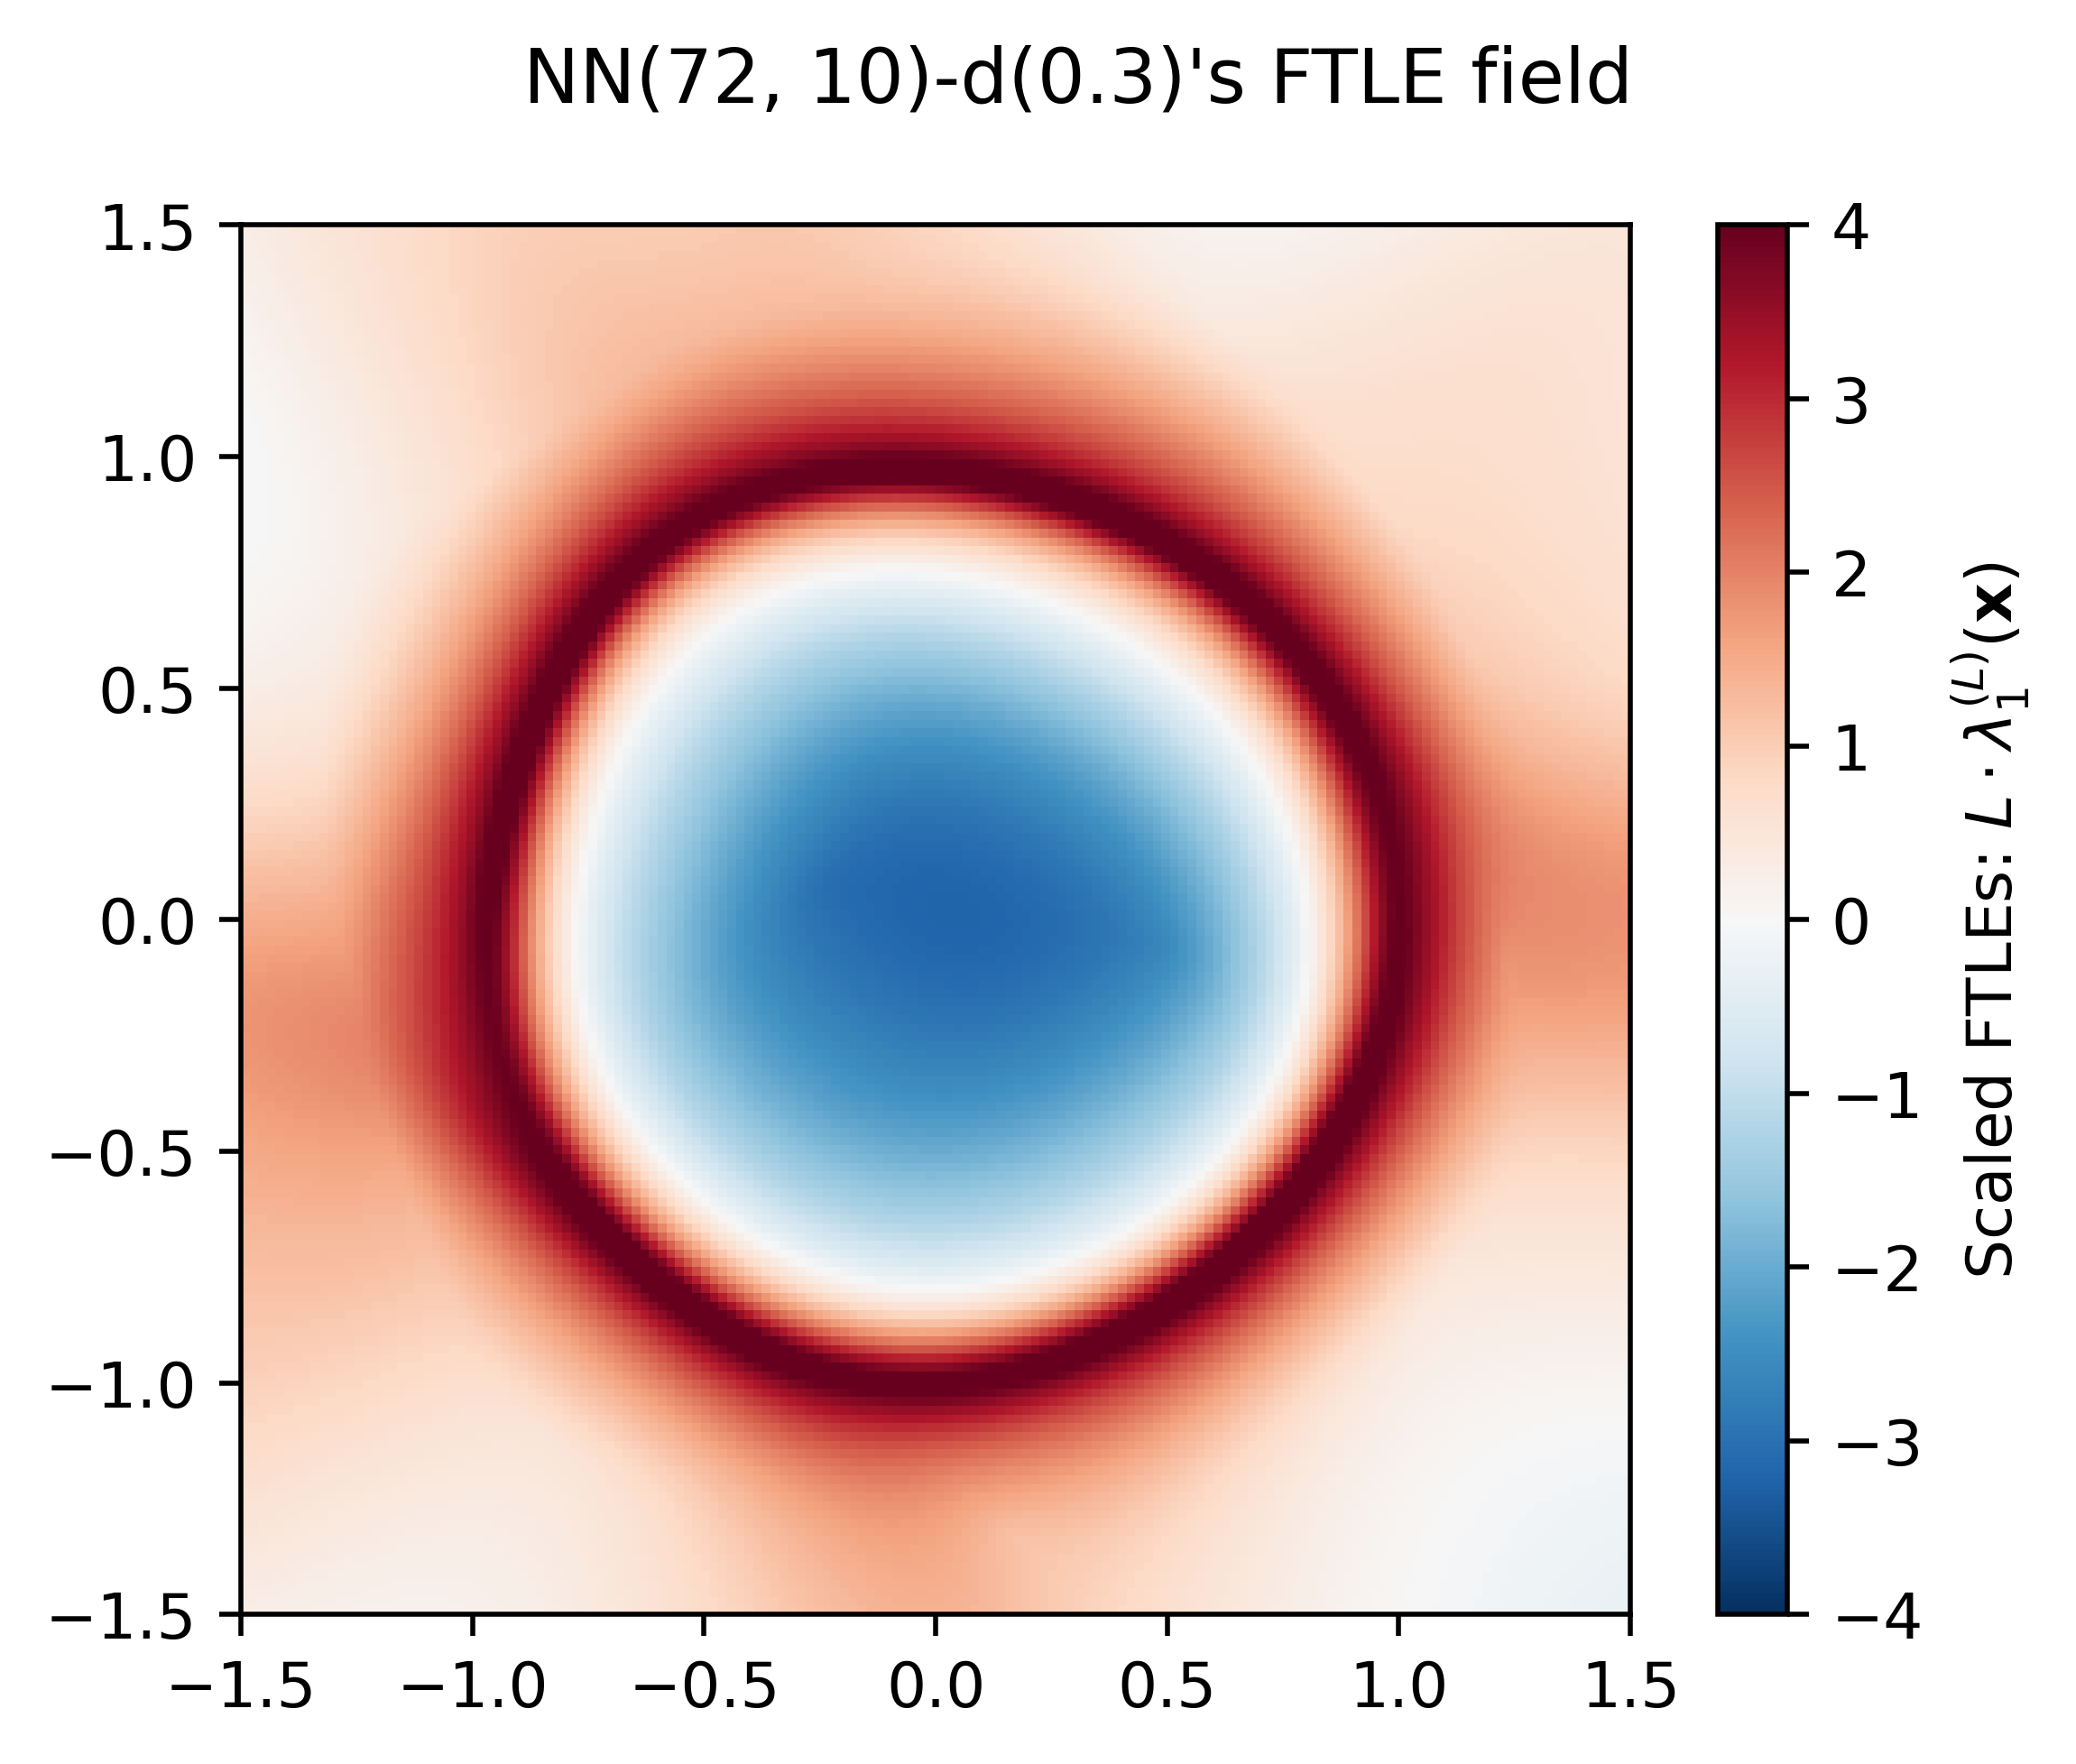

In [46]:
# 5) Plot (matplotlib)
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
Z1 = 10 * ftle1_drop.numpy().reshape(ny, nx)
fig = plt.figure(figsize=(5,4), dpi=500)
plt.imshow(Z1,
           extent=[-1.5,1.5,-1.5,1.5], 
           origin="lower", 
           aspect="equal",
           cmap="RdBu_r",
           norm=TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4))
plt.colorbar(label=r"Scaled FTLEs: $L\cdot\lambda_1^{(L)}(\mathbf{x})$", norm='log')
fig.suptitle(r"NN(72, 10)-d(0.3)'s FTLE field")
plt.show()

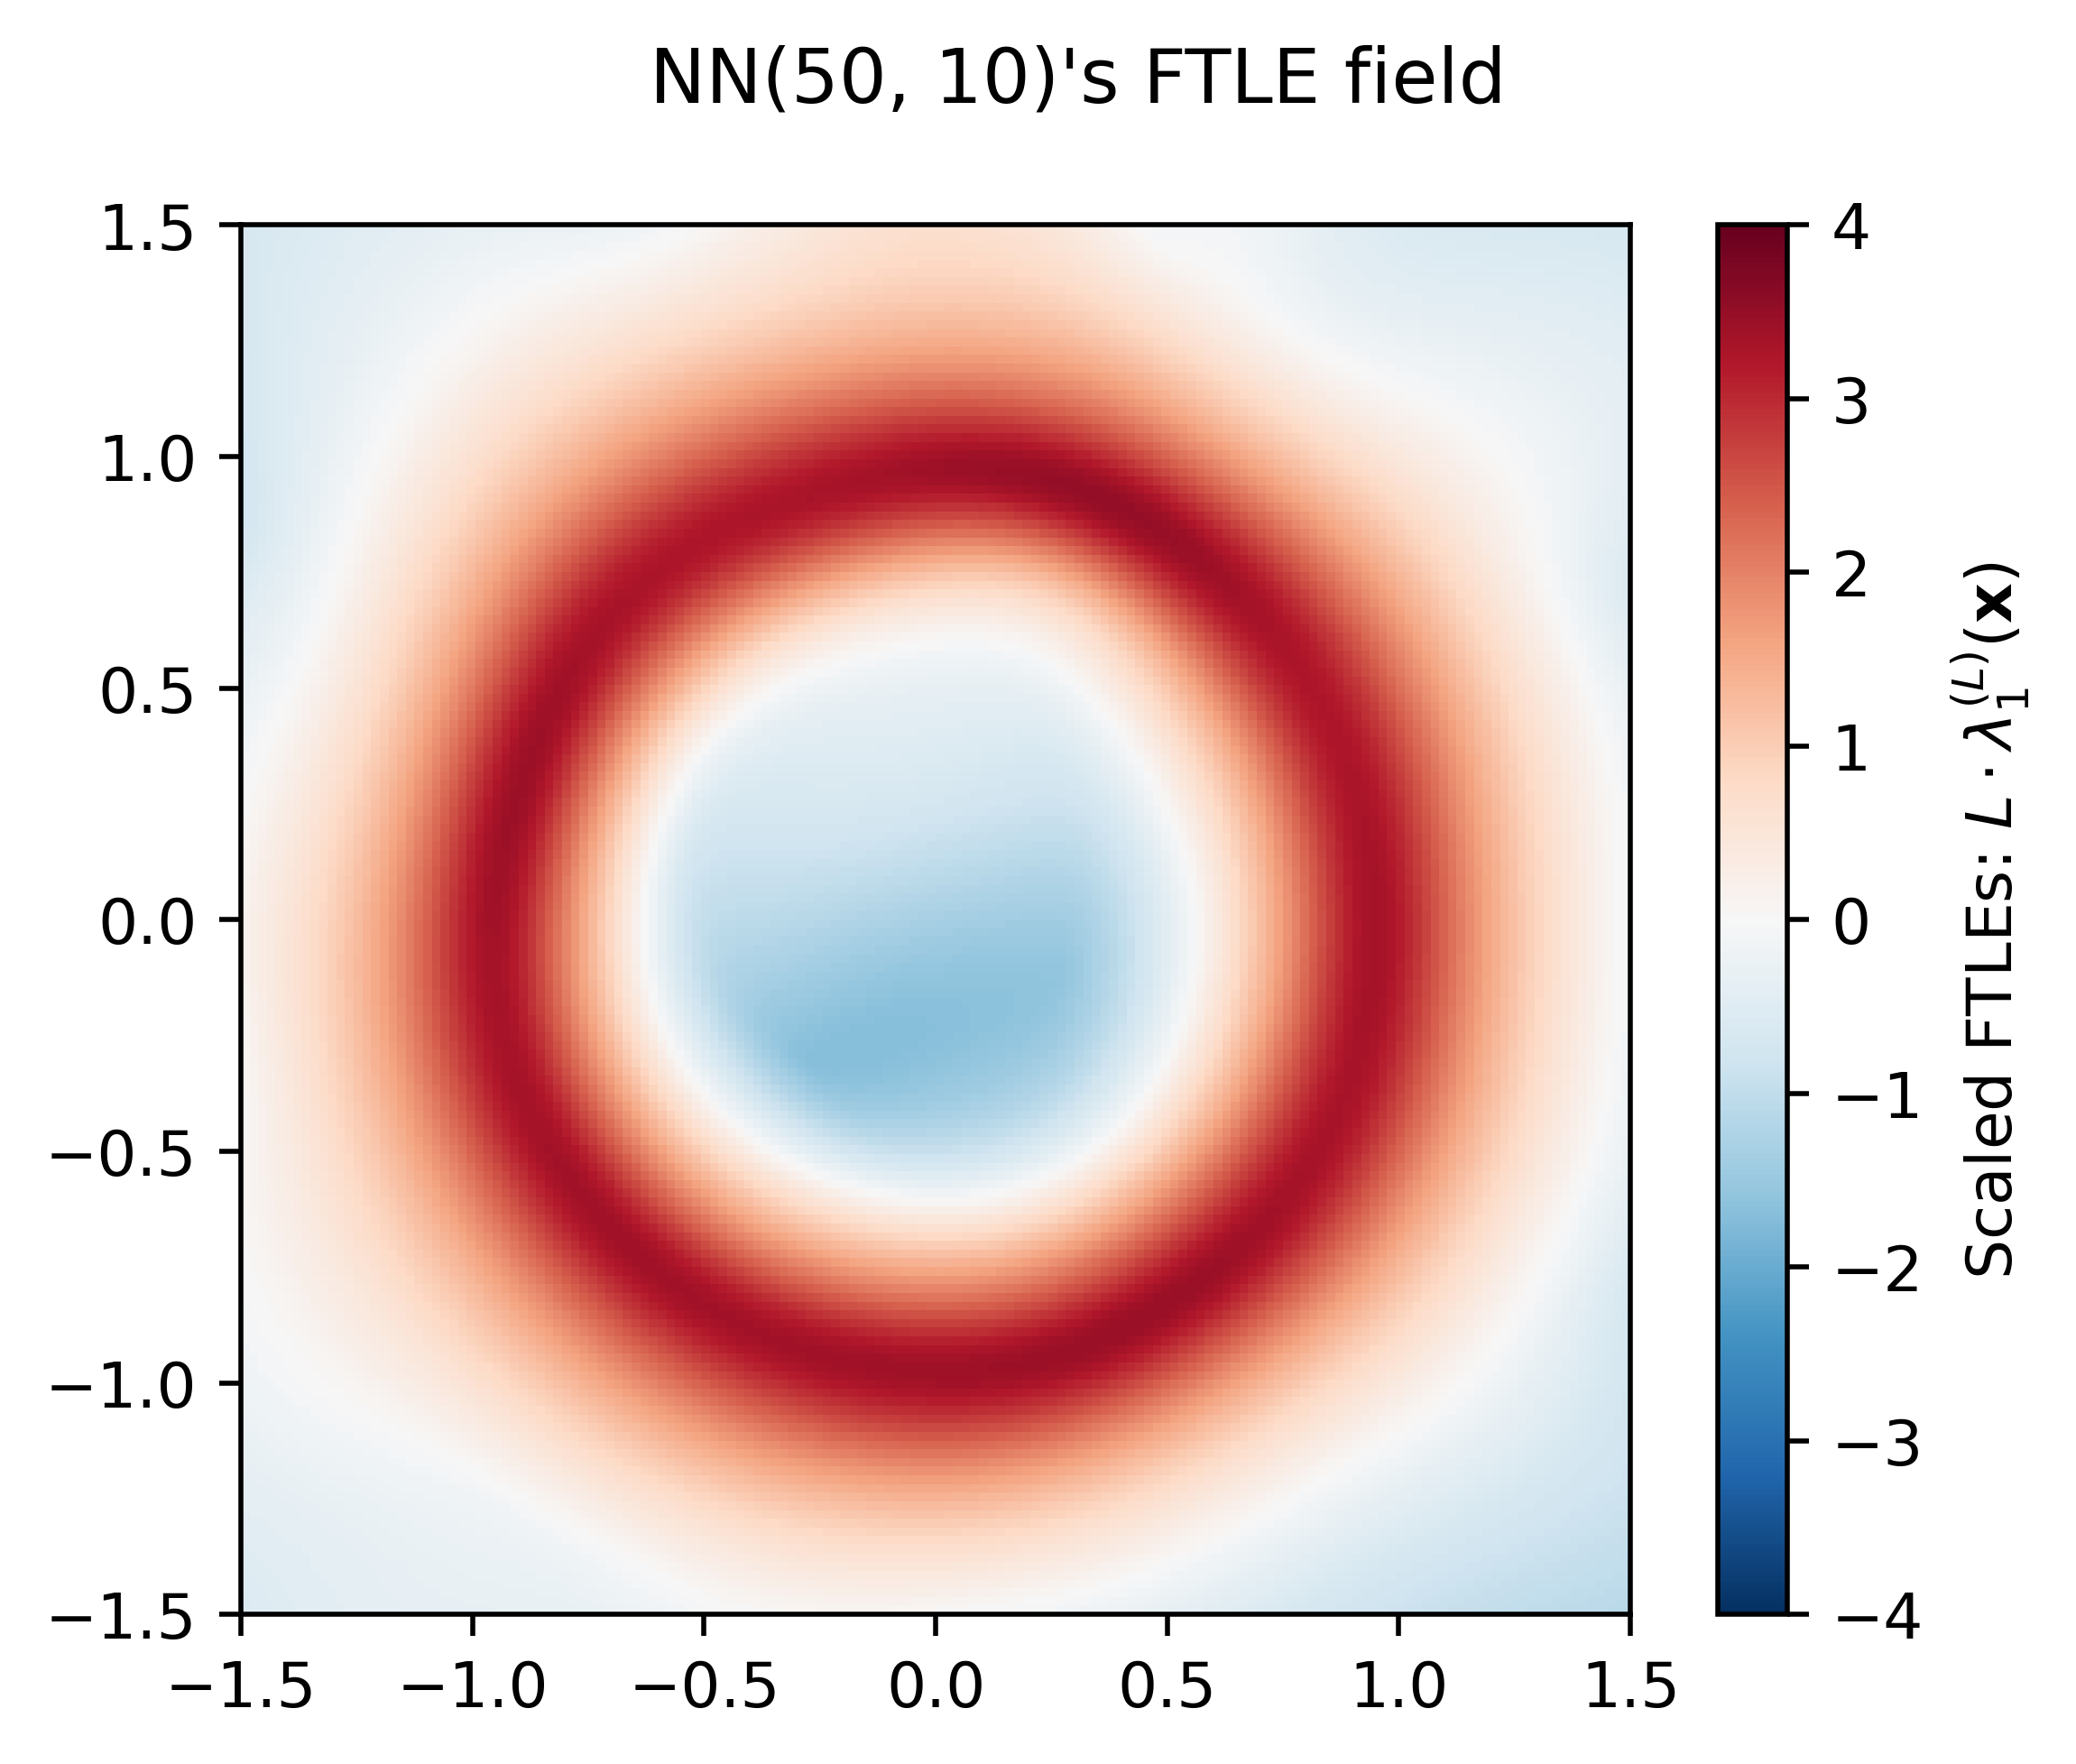

In [35]:
Z1 = 10 * ftle1_nodrop.numpy().reshape(ny, nx)
fig = plt.figure(figsize=(5,4), dpi=500)
plt.imshow(Z1,
           extent=[-1.5,1.5,-1.5,1.5], 
           origin="lower", 
           aspect="equal",
           cmap="RdBu_r",
           norm=TwoSlopeNorm(vmin=-4, vcenter=0, vmax=4))
plt.colorbar(label=r"Scaled FTLEs: $L\cdot\lambda_1^{(L)}(\mathbf{x})$", norm='log')
fig.suptitle(r"NN(50, 10)'s FTLE field")
plt.show()

#### Plotting the grid with second FTLEs (Optional):

In [ ]:
# Z2 = ftle2.numpy().reshape(ny, nx)
# plt.figure(figsize=(5,4))
# plt.imshow(Z2, extent=[-1.2,1.2,-1.2,1.2], origin="lower", aspect="equal", cmap="RdBu_r")
# plt.colorbar(label="FTLE (k=2)")
# plt.title("FTLE field (second largest)")
# plt.show()

### Defining the Circles Dataset

In [5]:
circles_data = split_dataset(X, y, val_size=0.2, 
                            val_to_use_as_test=0.2)

In [6]:
train_data = TensorDataset(*circles_data["train"])
val_data = TensorDataset(*circles_data["val"])
X_test, y_test = circles_data["test"][0], circles_data["test"][1]

In [7]:
train_size = len(train_data)
val_size = len(val_data)
test_size = len(X_test)

In [8]:
print("Train size: " + str(train_size), "Val size: " + str(val_size), "Test size: " + str(test_size), sep="\n")

Train size: 12000
Val size: 2400
Test size: 600


In [9]:
train_loader = DataLoader(train_data, batch_size=train_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=val_size)

### Lazy Training

In [11]:
### Experiment Number ###

experiment_number = 3

In [12]:
ell = 2
n_list = [3, 5, 10, 20, 30, 50, 60, 70,
          80, 85, 90, 95, 100, 110, 120,
          150, 200, 250, 300, 350, 400,
          450, 500, 550, 600, 650, 700,
          800, 900, 950, 1000]

In [14]:
networks_frozen_params = {}
networks_frozen = {}

networks_usual_params = {}
networks_usual = {}

for j, n in enumerate(n_list):
    networks_frozen_params[f"NET({n}, {ell})-frozen"] = {
        "net_params": 
        {
            "hidden_dim": n,
            "hidden_depth": ell,
            "input_dim": 2,
            "output_dim": 1
        },
        "train_config":
        TrainConfig(
            lr=1e-2, # 3e-2 * (64 / n), # 0.05, 1e-2
            epochs=1000, # 2500,
            batch_size=train_size, # 256,
            loss='mse', # CrossEntropyLoss for multi-class classification
            optimizer='sgd',
            weight_decay=0.0,
            save_dir=f'lazy_training/experiment_{experiment_number}/lazy_models',
            model_name=f'({n}, {ell})-frozen',
            momentum=0.0,
            print_every=200, #200
            train_only_output=True
            #train_last_n_linears=2
        )
    }

    networks_usual_params[f"NET({n}, {ell})-usual"] = {
        "net_params": 
        {
            "hidden_dim": n,
            "hidden_depth": ell,
            "input_dim": 2,
            "output_dim": 1
        },
        "train_config":
        TrainConfig(
            lr=1e-2, # 0.05,
            epochs=1000, # 2500
            batch_size=train_size, # 256
            loss='mse',
            optimizer='sgd',
            weight_decay=0.0,
            save_dir=f'lazy_training/experiment_{experiment_number}/usual_models',
            model_name=f'({n}, {ell})-usual',
            momentum=0.0,
            print_every=200
        )
    }


In [15]:
for key in networks_frozen_params.keys():
    net_params = networks_frozen_params[key]["net_params"]
    train_config = networks_frozen_params[key]["train_config"]

    model = CustomDNN(**net_params)
    trainer = Trainer(model=model, cfg=train_config)
    
    print(f"Training {key}: (N={net_params['hidden_dim']}, L={net_params['hidden_depth']})")
    history = trainer.train(train_loader=train_loader, val_loader=val_loader)

    networks_frozen[key] = {"network": model,
                            "history": history}
    print("\n")

Trainer for MODEL_(3, 2)-frozen was initialized on device: cuda
[Freeze] training only output layer: net.4
Trainable parameters: 4 / 25
Training NET(3, 2)-frozen: (N=3, L=2)
Training started...


Epoch 200/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 63.80it/s]


Epoch 200/1000 | Train Loss: 0.6457 | Val Loss: 0.6474 | Val Acc: 79.92%
Validation loss improved from 0.6474 to 0.6474. Saving the best model.


Epoch 400/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 81.06it/s]


Epoch 400/1000 | Train Loss: 0.6434 | Val Loss: 0.6451 | Val Acc: 79.92%
Validation loss improved from 0.6451 to 0.6451. Saving the best model.


...

Epoch 600/1000 | Train Loss: 0.6263 | Val Loss: 0.6293 | Val Acc: 79.92%
Validation loss improved from 0.6293 to 0.6293. Saving the best model.


Epoch 800/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 76.14it/s]


Epoch 800/1000 | Train Loss: 0.6125 | Val Loss: 0.6166 | Val Acc: 81.21%
Validation loss improved from 0.6167 to 0.6166. Saving the best model.


Epoch 1000/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 73.96it/s]

Epoch 1000/1000 | Train Loss: 0.5995 | Val Loss: 0.6043 | Val Acc: 83.04%
Validation loss improved from 0.6044 to 0.6043. Saving the best model.
Training finished.




In [16]:
for key in networks_frozen:
    torch.save(networks_frozen[key]["network"], f"lazy_training/experiment_{experiment_number}/frozen_static/"+ key + ".pt")

In [27]:
def evaluate_mse(model, X, y):
    device = device_string()
    model.eval()
    with torch.no_grad():
        X = X.to(device); y = y.to(device)
        out = model(X)
    return ((out - y) ** 2).mean().detach().cpu().item()

In [17]:
for key in networks_usual_params.keys():
    net_params = networks_usual_params[key]["net_params"]
    
    train_config = networks_usual_params[key]["train_config"]
    
    model = CustomDNN(**net_params)
    trainer = Trainer(model=model, cfg=train_config)
    print(f"Training {key}: (N={net_params['hidden_dim']}, L={net_params['hidden_depth']})")
    history = trainer.train(train_loader=train_loader, val_loader=val_loader)

    networks_usual[key] = {"network": model,
                            "history": history}
    print("\n")

Trainer for MODEL_(3, 2)-usual was initialized on device: cuda
Trainable parameters: 25 / 25
Training NET(3, 2)-usual: (N=3, L=2)
Training started...


Epoch 200/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 89.20it/s]


Epoch 200/1000 | Train Loss: 0.6453 | Val Loss: 0.6444 | Val Acc: 79.92%
Validation loss improved from 0.6445 to 0.6444. Saving the best model.


Epoch 400/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 82.46it/s]


Epoch 400/1000 | Train Loss: 0.6236 | Val Loss: 0.6223 | Val Acc: 79.92%
Validation loss improved from 0.6225 to 0.6223. Saving the best model.


...

Epoch 600/1000 | Train Loss: 0.5465 | Val Loss: 0.5445 | Val Acc: 82.83%
Validation loss improved from 0.5454 to 0.5445. Saving the best model.


Epoch 800/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00,  4.18it/s]


Epoch 800/1000 | Train Loss: 0.5988 | Val Loss: 0.5757 | Val Acc: 84.38%


Epoch 1000/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 54.78it/s]

Epoch 1000/1000 | Train Loss: 0.4448 | Val Loss: 0.4118 | Val Acc: 88.67%
Training finished.




In [18]:
for key in networks_usual:
    torch.save(networks_usual[key]["network"], f"lazy_training/experiment_{experiment_number}/usual_static/"+ key + ".pt")

In [19]:
networks_frozen_random_params = {}
networks_frozen_random = {}

for j, n in enumerate(n_list):
    networks_frozen_random_params[f"NET({n}, {ell})-frozen_random"] = {
        "net_params": 
        {
            "hidden_dim": n,
            "hidden_depth": ell,
            "input_dim": 2,
            "output_dim": 1,
            "init_method": None
        },
        "train_config":
        TrainConfig(
            lr=1e-2, # 0.05,
            epochs=1000, # 2500,
            batch_size=train_size, # 256,
            loss='mse', # CrossEntropyLoss for multi-class classification
            optimizer='sgd',
            weight_decay=0.0,
            save_dir=f'lazy_training/experiment_{experiment_number}/lazy_models_random_weights',
            model_name=f'({n}, {ell})-frozen',
            momentum=0.0,
            print_every=200, #200
            train_only_output=True
            #train_last_n_linears=2
        )
    }


In [20]:
for key in networks_frozen_random_params.keys():
    net_params = networks_frozen_random_params[key]["net_params"]
    train_config = networks_frozen_random_params[key]["train_config"]
    
    model = CustomDNN(**net_params)
    trainer = Trainer(model=model, cfg=train_config)
    print(f"Training {key}: (N={net_params['hidden_dim']}, L={net_params['hidden_depth']})")
    history = trainer.train(train_loader=train_loader, val_loader=val_loader)

    networks_frozen_random[key] = {"network": model,
                            "history": history}
    print("\n")

Trainer for MODEL_(3, 2)-frozen was initialized on device: cuda
[Freeze] training only output layer: net.4
Trainable parameters: 4 / 25
Training NET(3, 2)-frozen_random: (N=3, L=2)
Training started...


Epoch 200/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 78.16it/s]


Epoch 200/1000 | Train Loss: 0.6536 | Val Loss: 0.6552 | Val Acc: 79.92%
Validation loss improved from 0.6552 to 0.6552. Saving the best model.


Epoch 400/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00,  3.69it/s]


Epoch 400/1000 | Train Loss: 0.6434 | Val Loss: 0.6452 | Val Acc: 79.92%
Validation loss improved from 0.6452 to 0.6452. Saving the best model.


...

Epoch 600/1000 | Train Loss: 0.2401 | Val Loss: 0.2388 | Val Acc: 96.62%
Validation loss improved from 0.2390 to 0.2388. Saving the best model.


Epoch 800/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 37.24it/s]


Epoch 800/1000 | Train Loss: 0.2080 | Val Loss: 0.2070 | Val Acc: 97.33%
Validation loss improved from 0.2072 to 0.2070. Saving the best model.


Epoch 1000/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00,  3.94it/s]

Epoch 1000/1000 | Train Loss: 0.1873 | Val Loss: 0.1865 | Val Acc: 98.08%
Validation loss improved from 0.1866 to 0.1865. Saving the best model.
Training finished.




In [21]:
for key in networks_frozen_random:
    torch.save(networks_frozen_random[key]["network"], f"lazy_training/experiment_{experiment_number}/frozen_random_static/"+ key + ".pt")

loading models (optional)

In [28]:
frozen_mods = []
usual_mods = []
frozen_random_mods = []
for i in n_list:
    frozen_mods.append(torch.load(f"lazy_training/experiment_{experiment_number}/lazy_models/BEST_MODEL({i}, 2)-frozen.pt"))
    usual_mods.append(torch.load(f"lazy_training/experiment_{experiment_number}/usual_models/BEST_MODEL({i}, 2)-usual.pt"))
    frozen_random_mods.append(torch.load(f"lazy_training/experiment_{experiment_number}/lazy_models_random_weights/BEST_MODEL({i}, 2)-frozen.pt"))

plot the loss vs logits MSE instead of accuracy

In [51]:
test_mse_f = []
test_mse_u = []
test_mse_fr = []

test_acc_f = []
test_acc_u = []
test_acc_fr = []

device = device_string()

for i, (val_1, val_2, val_3) in enumerate(zip(networks_frozen_params.values(),
                                              networks_usual_params.values(),
                                              networks_frozen_random_params.values())):
    
    model_1 = CustomDNN(**val_1['net_params']); model_1.to(device)
    model_1.load_state_dict(frozen_mods[i]["model_state_dict"])

    model_2 = CustomDNN(**val_2['net_params']); model_2.to(device)
    model_2.load_state_dict(usual_mods[i]["model_state_dict"])

    model_3 = CustomDNN(**val_3['net_params']); model_3.to(device)
    model_3.load_state_dict(frozen_random_mods[i]["model_state_dict"])
    
    test_mse_f.append(evaluate_mse(model_1, X_test, y_test))
    test_mse_u.append(evaluate_mse(model_2, X_test, y_test))
    test_mse_fr.append(evaluate_mse(model_3, X_test, y_test))

    test_acc_f.append(100 * (1 - evaluate_accuracy(model_1, X_test, y_test)))
    test_acc_u.append(100 * (1 - evaluate_accuracy(model_2, X_test, y_test)))
    test_acc_fr.append(100 * (1 - evaluate_accuracy(model_3, X_test, y_test)))

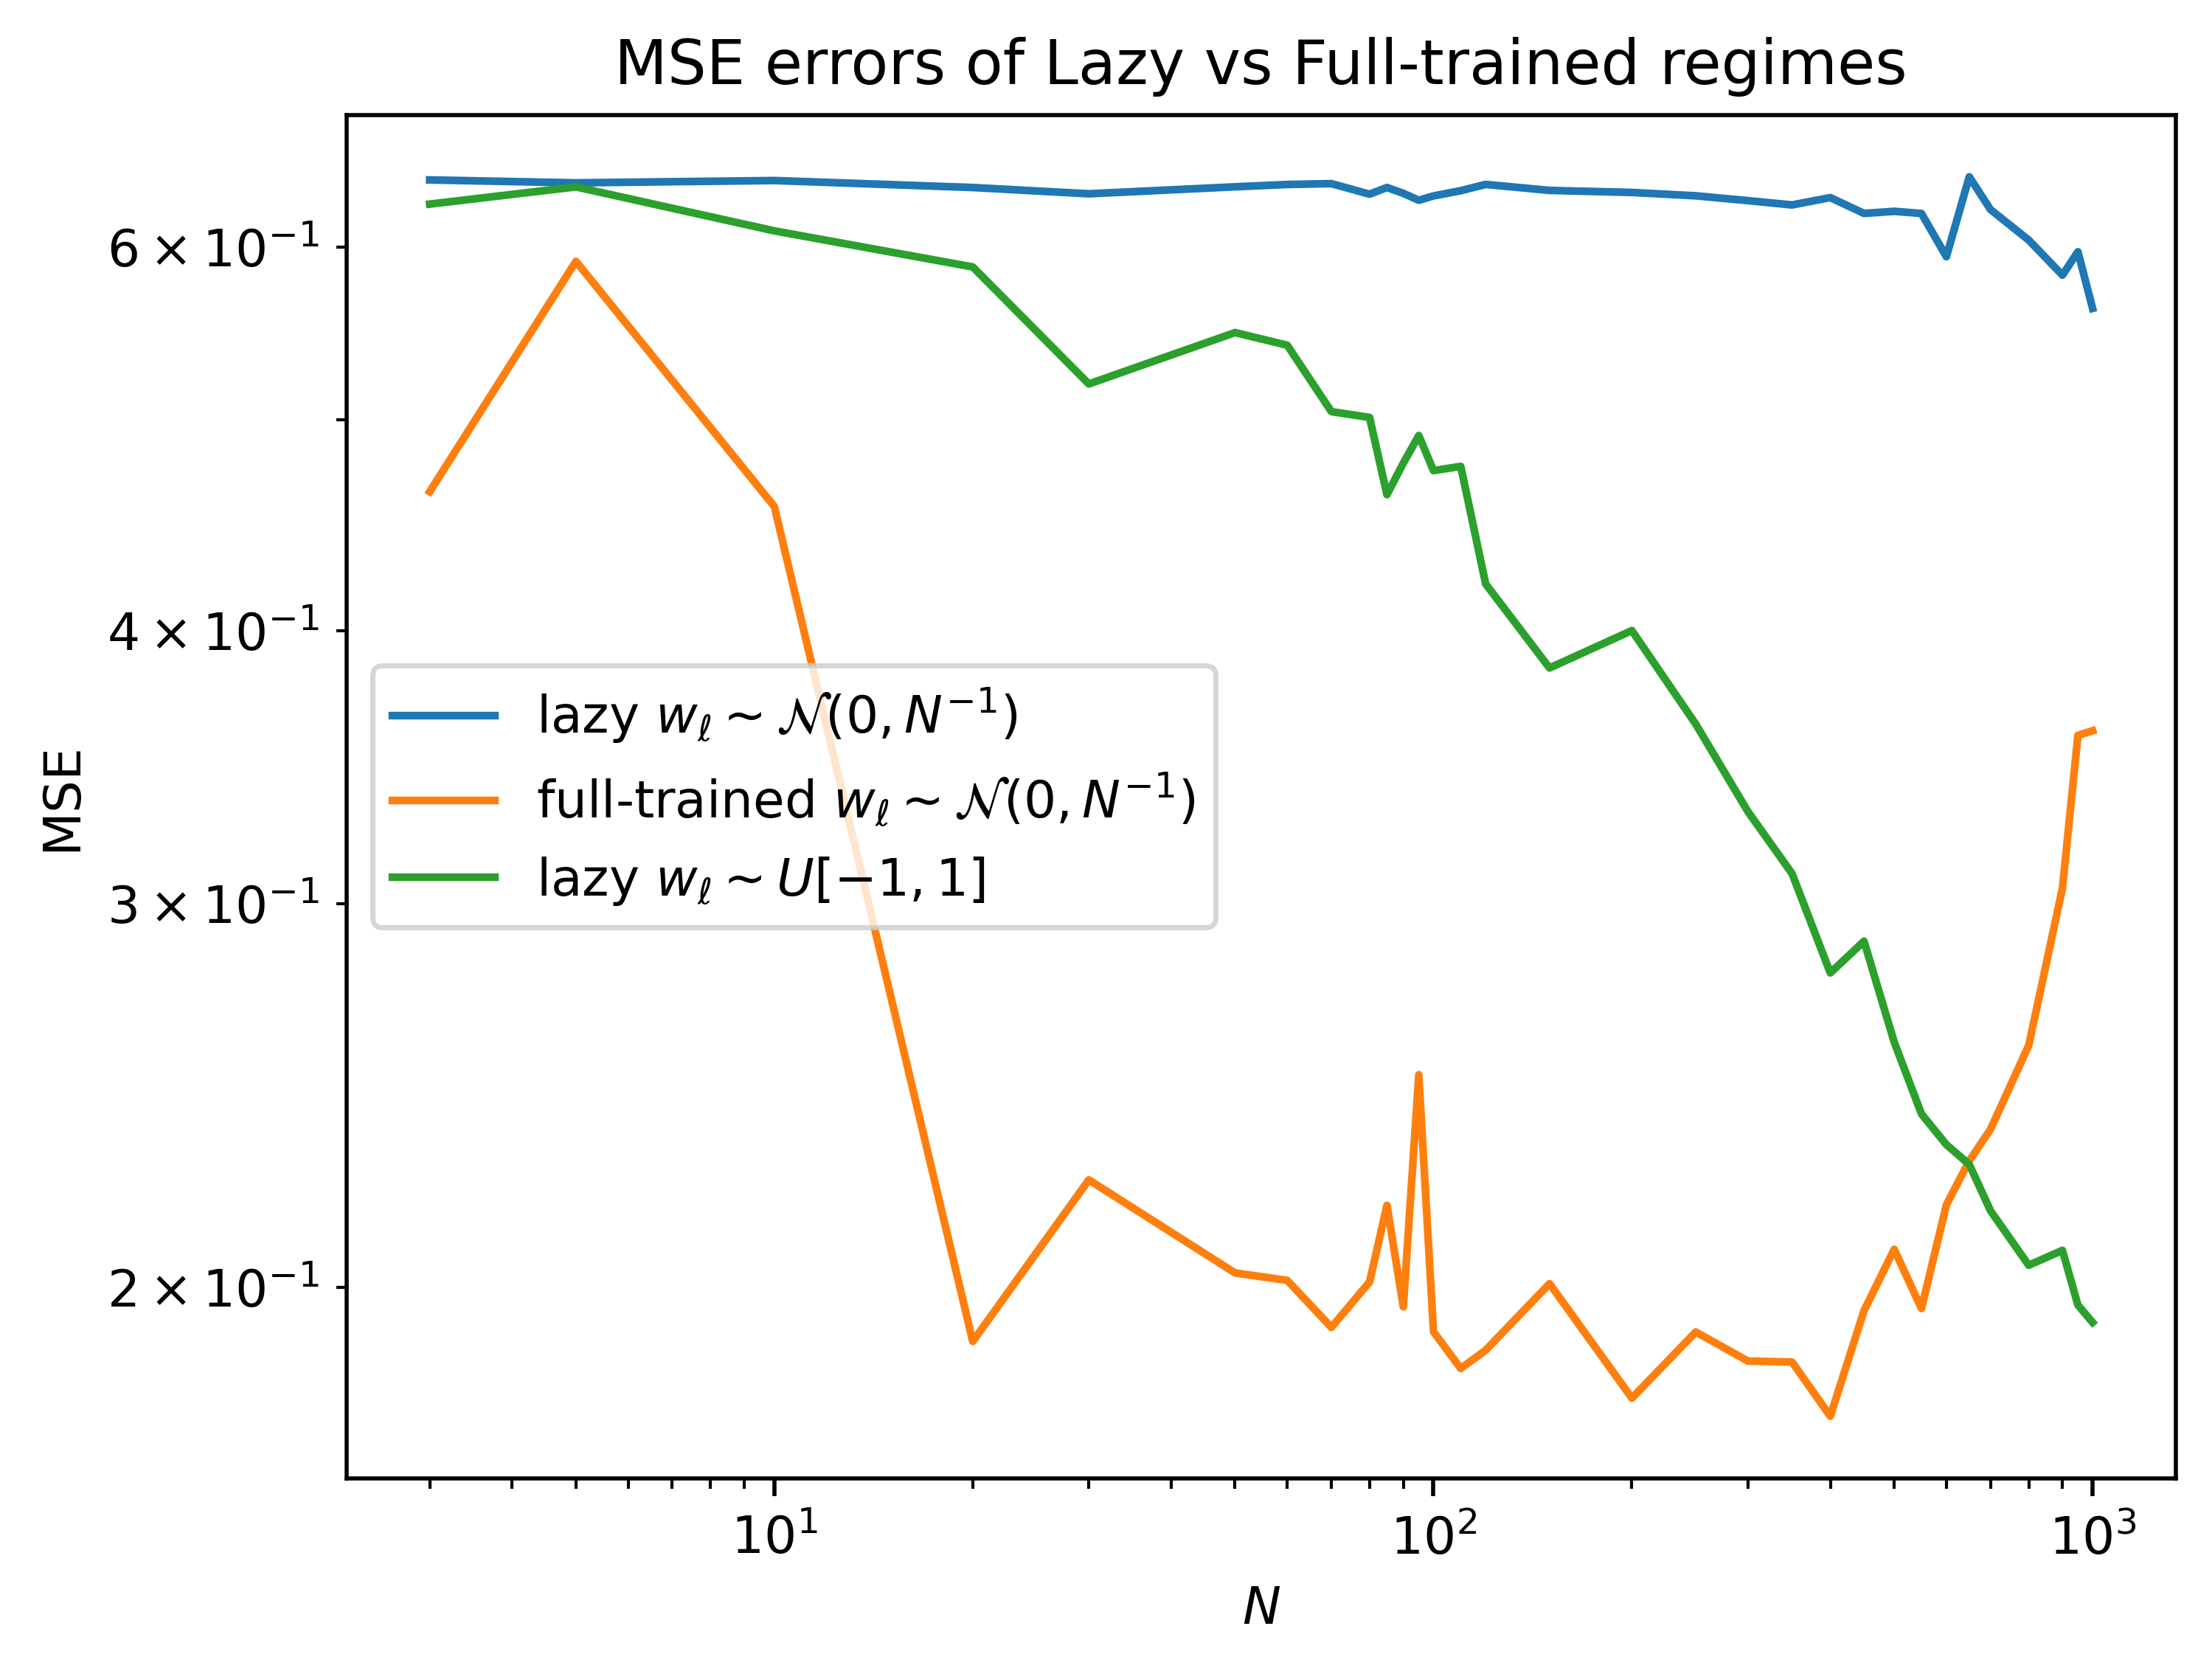

In [56]:
plt.figure(dpi=500)
plt.plot(n_list, test_mse_f, label='lazy $w_\ell\sim \mathcal{N}(0, N^{-1})$')
plt.plot(n_list, test_mse_u, label='full-trained $w_\ell\sim\mathcal{N}(0, N^{-1})$')
plt.plot(n_list, test_mse_fr, label='lazy $w_\ell\sim U[-1,1]$')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.title('MSE errors of Lazy vs Full-trained regimes')
plt.xlabel('$N$')
plt.ylabel('MSE')
plt.show()

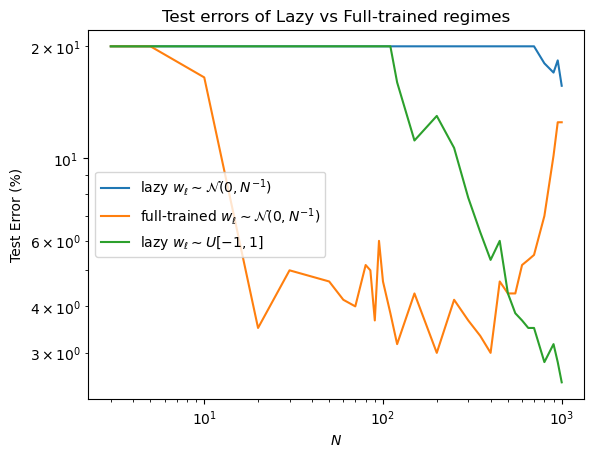

In [54]:
plt.plot(n_list, test_acc_f, label='lazy $w_\ell\sim \mathcal{N}(0, N^{-1})$')
plt.plot(n_list, test_acc_u, label='full-trained $w_\ell\sim\mathcal{N}(0, N^{-1})$')
plt.plot(n_list, test_acc_fr, label='lazy $w_\ell\sim U[-1,1]$')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.title('Test errors of Lazy vs Full-trained regimes')
plt.xlabel('$N$')
plt.ylabel('Test Error (%)')
plt.show()

### Small FTLE grid

In [12]:
experiment_number_grid = 1

###

In [13]:
n_list = [3, 10, 50, 100, 250]
ell_list = [2, 4, 6, 8, 12]

networks_grid_params = {}
networks_grid = {}

for ell in ell_list:
    for n in n_list:
        networks_grid_params[f"NET({n}, {ell})-frozen"] = {
            "net_params": 
            {
                "hidden_dim": n,
                "hidden_depth": ell,
                "input_dim": 2,
                "output_dim": 1
            },
            "train_config":
            TrainConfig(
                lr=1e-2, # 3e-2 * (64 / n), # 0.05, 1e-2
                epochs=1000, # 2500,
                batch_size=train_size, # 256,
                loss='mse', # CrossEntropyLoss for multi-class classification
                optimizer='sgd',
                weight_decay=0.0,
                save_dir=f'network_grid/experiment_{experiment_number_grid}',
                model_name=f'({n}, {ell})',
                momentum=0.0,
                print_every=200, #200
            )
        }


In [59]:
for key in networks_grid_params.keys():
    net_params = networks_grid_params[key]["net_params"]
    train_config = networks_grid_params[key]["train_config"]
    
    model = CustomDNN(**net_params)
    trainer = Trainer(model=model, cfg=train_config)
    print(f"Training {key}: (N={net_params['hidden_dim']}, L={net_params['hidden_depth']})")
    history = trainer.train(train_loader=train_loader, val_loader=val_loader)

    networks_grid[key] = {"network": model,
                          "history": history}
    print("\n")

Trainer for MODEL_(3, 2) was initialized on device: cuda
Trainable parameters: 25 / 25
Training NET(3, 2)-frozen: (N=3, L=2)
Training started...


Epoch 200/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 40.16it/s]


Epoch 200/1000 | Train Loss: 0.6491 | Val Loss: 0.6496 | Val Acc: 79.92%
Validation loss improved from 0.6497 to 0.6496. Saving the best model.


Epoch 400/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 68.25it/s]


Epoch 400/1000 | Train Loss: 0.6361 | Val Loss: 0.6366 | Val Acc: 79.92%
Validation loss improved from 0.6366 to 0.6366. Saving the best model.


...

Epoch 600/1000 | Train Loss: 0.0865 | Val Loss: 0.0837 | Val Acc: 96.75%


Epoch 800/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 47.55it/s]


Epoch 800/1000 | Train Loss: 0.0614 | Val Loss: 0.0658 | Val Acc: 97.46%


Epoch 1000/1000 [Validation]: 100%|██████████| 1/1 [00:00<00:00, 47.99it/s]

Epoch 1000/1000 | Train Loss: 0.0473 | Val Loss: 0.0485 | Val Acc: 98.25%
Validation loss improved from 0.0487 to 0.0485. Saving the best model.
Training finished.




In [16]:
# 1) Make the grid (2D inputs)
nx, ny = 120, 120
grid, (XX, YY) = make_grid2d(-2, 2, -2, 2, nx=nx, ny=ny)
cfg = SVConfig(exact_if_dim_le=4, jvp_backend="auto")
ftle_grid_collection = []

In [67]:


for i, net in enumerate(networks_grid.values()):

    L = ell_list[i//5]
    layer = ("hidden_k", L)
    ftle_grid_collection.append(compute_ftle_grid(net["network"], layer,
                                                  L, grid, k=1, cfg=cfg,
                                                  batch_size=2048, show_progress=True))
    print(L)


FTLE(k=1) grid:   0%|          | 0/8 [00:00<?, ?it/s]

2


FTLE(k=1) grid:   0%|          | 0/8 [00:00<?, ?it/s]

2


FTLE(k=1) grid:   0%|          | 0/8 [00:00<?, ?it/s]

...

12


FTLE(k=1) grid:   0%|          | 0/8 [00:00<?, ?it/s]

12


FTLE(k=1) grid:   0%|          | 0/8 [00:00<?, ?it/s]

12


In [71]:
torch.save(ftle_grid_collection, f"network_grid/experiment_{experiment_number_grid}/ftle_grid_full.pt")

In [10]:
ftle_grid_collection_loaded = torch.load("network_grid/experiment_1/ftle_grid_full.pt")

In [21]:
ftle_grid_collection_loaded[0]

torch.Size([14400])

In [22]:
ell_list

[2, 4, 6, 8, 12]

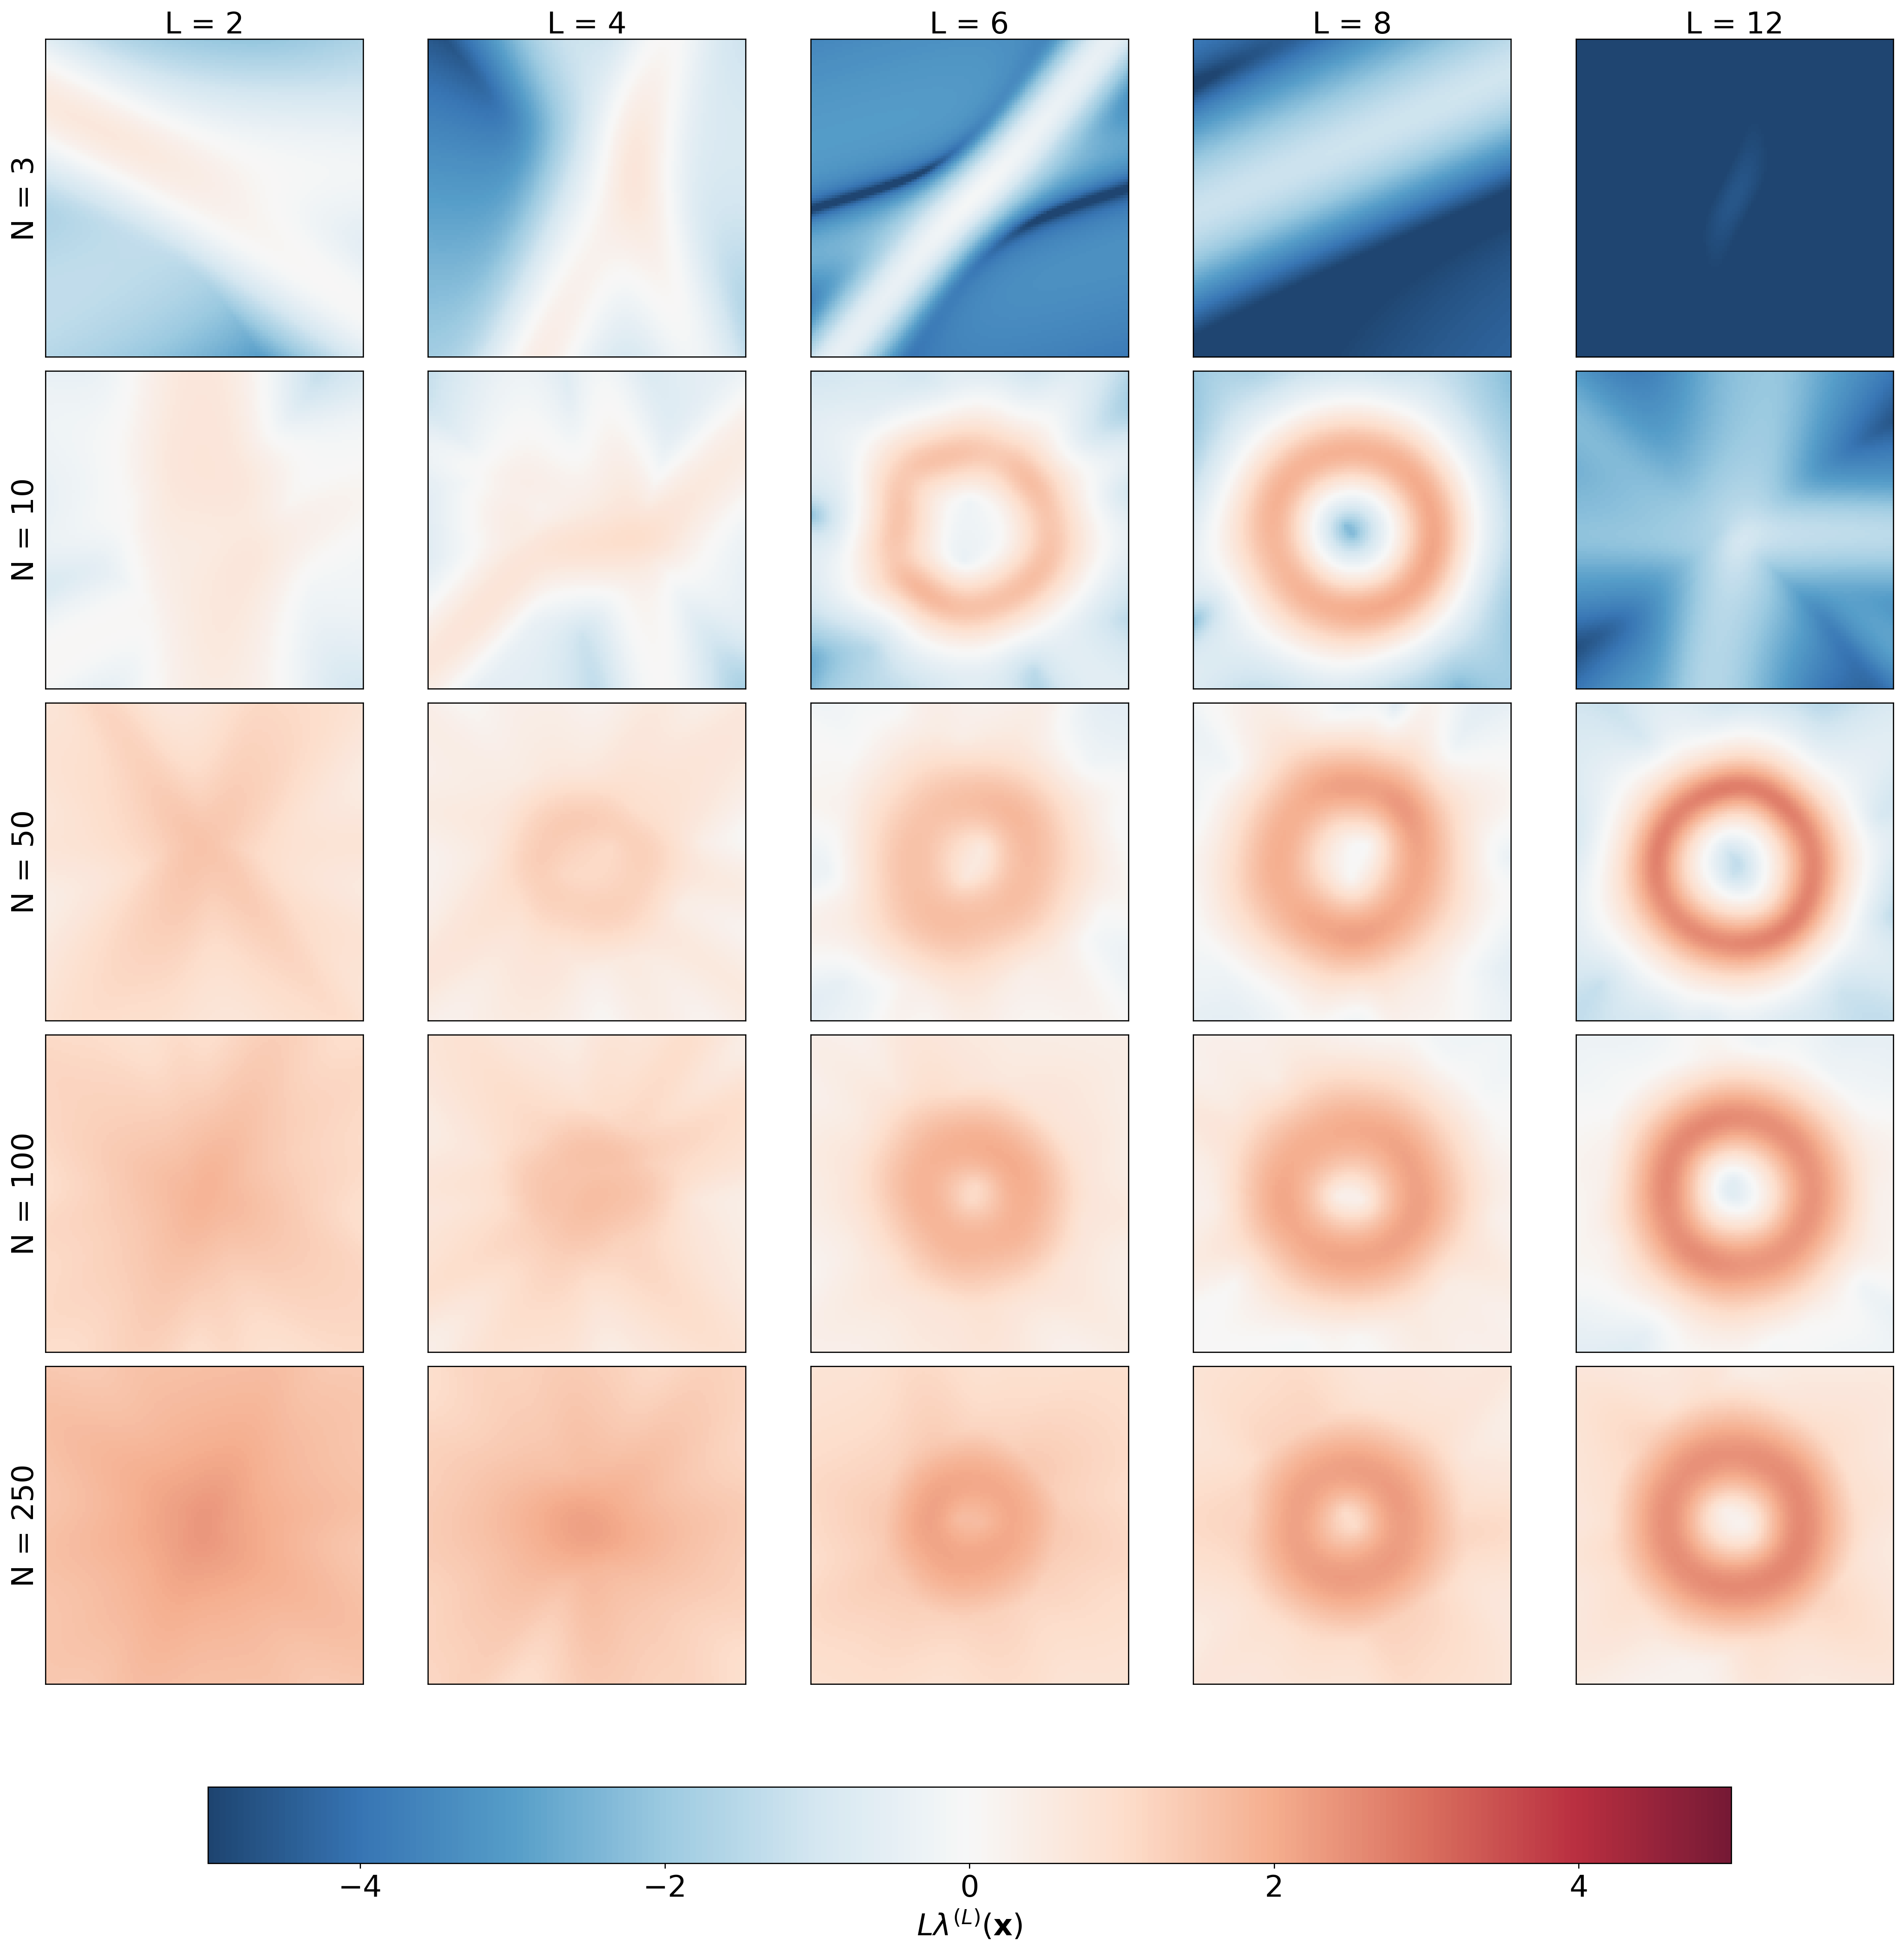

In [33]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np

fig = plt.figure(constrained_layout=True, figsize=(18,18), dpi=250)
axes = fig.subplots(5, 5)

# Iterate over each grid
for i, result in enumerate(ftle_grid_collection_loaded):
    ax = axes[i%5, i//5]
    L = ell_list[i//5]
    lyapunov_exponents = L * result.numpy().reshape(ny, nx)
    
    # Plot the heatmap
    im = ax.imshow(lyapunov_exponents,
                   extent=[-2, 2, -2, 2],
                   origin='lower',
                   cmap='RdBu_r',
                   alpha=0.9,
                  norm=TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)) # vmin/vmax=-+4
    
    # Add vector field

    if not i % 5:
        ax.set_xlabel(f"L = {ell_list[i//5]}", fontsize=20)
        ax.xaxis.set_label_position('top') 
    if i in range(5):
        ax.set_ylabel(f"N = {n_list[i]}", fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([])

# Add a colorbar to the right of the figure
# plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.1)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    orientation='horizontal',
                    location='bottom',
                    shrink=0.8)
                    # fraction=0.08, pad=0.05)
cbar.set_label(r"$L\lambda^{(L)}(\mathbf{x})$",fontsize=20)
cbar.ax.tick_params(labelsize=20)
# cbar.ax.xaxis.set_label_position('top')
# cbar.ax.xaxis.tick_top()
plt.show()


### Ridge averages experiment

### Level Sets